In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from scipy.ndimage import gaussian_filter
import pandas as pd
import colormaps as cmaps
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [2]:
# source = "scream"
source = "era5"

out_dir = f"/pscratch/sd/w/wcmca1/hackathon/etc_data/stats/{source}/"
# Create output directory if it doesn't exist
os.makedirs(out_dir, exist_ok=True)

# ETC COF parquet file
etc_path = "/pscratch/sd/w/wcmca1/hackathon/etc_tracks/"
etc_file = f"{etc_path}/{source}_etc_cof_data.parquet"
print(f"{etc_file} exists: {os.path.isfile(etc_file)}")

/pscratch/sd/w/wcmca1/hackathon/etc_tracks//era5_etc_cof_data.parquet exists: True


In [3]:
# ETC 2D Zarr file
zarr_path = f"/pscratch/sd/w/wcmca1/hackathon/etc_data/{source}/"
zarr_file = f"{zarr_path}/etc_2d_combined_all_all.zarr"
print(f"{zarr_file} exists: {os.path.isdir(zarr_file)}")

/pscratch/sd/w/wcmca1/hackathon/etc_data/era5//etc_2d_combined_all_all.zarr exists: True


In [4]:
etc_df = pd.read_parquet(etc_file)
etc_df.head()

,storm_id,lon_id,lat_id,lon,lat,year,month,day,hour,base_time,overlap_flag,ar_tracks,mcs_tracks
0,1,225,142,56.25,54.5,2019,8,1,0,2019-08-01 00:00:00,2.0,[1.0],[]
1,1,224,136,56.00,56.0,2019,8,1,6,2019-08-01 06:00:00,3.0,[1.0],[93.0]
2,1,240,132,60.00,57.0,2019,8,1,12,2019-08-01 12:00:00,3.0,[1.0],[93.0]
3,1,244,130,61.00,57.5,2019,8,1,18,2019-08-01 18:00:00,3.0,[1.0],[93.0]
4,1,244,128,61.00,58.0,2019,8,2,0,2019-08-02 00:00:00,2.0,[1.0],[]


In [5]:
ds = xr.open_zarr(zarr_file, consolidated=True)
ds

<xarray.Dataset> Size: 45GB
Dimensions:                  (time: 28945, y: 161, x: 161)
Coordinates:
  * time                     (time) datetime64[ns] 232kB 2019-08-01 ... 2021-...
  * x                        (x) int64 1kB -80 -79 -78 -77 -76 ... 77 78 79 80
  * y                        (y) int64 1kB -80 -79 -78 -77 -76 ... 77 78 79 80
Data variables: (12/20)
    ar_mcs_etc_overlap_mask  (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    etc_mcs_ar_overlap_mask  (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    hur_500hPa               (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    hur_850hPa               (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    hus_500hPa               (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    hus_850hPa               (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    ...                       ...
    ua_500hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    ua_850hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    va_500hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    va_850hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    zg_500hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    zg_850hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
Attributes:
    combination_date:    2025-11-17T15:43:37
    combined_variables:  ar_mcs_etc_overlap_mask, etc_mcs_ar_overlap_mask, hu...
    creation_time:       2025-11-16T16:15:34.336380
    description:         ETC storm extracted 2D data with relative coordinates
    grid_center_x:       0
    grid_center_y:       0
    lat_res:             0.25
    lon_res:             0.25
    num_variables:       15
    radius:              20.0

In [6]:
ds.storm_id

<xarray.DataArray 'storm_id' (time: 28945)> Size: 232kB
dask.array<open_dataset-storm_id, shape=(28945,), dtype=int64, chunksize=(28945,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 232kB 2019-08-01 ... 2021-03-31T18:00:00
Attributes:
    description:  ETC storm identifier
    long_name:    Storm ID

In [7]:
etc_df['ar_tracks']

0        [1.0]
1        [1.0]
2        [1.0]
3        [1.0]
4        [1.0]
         ...  
31706     None
31707     None
31708     None
31709     None
31710     None
Name: ar_tracks, Length: 31711, dtype: object

# Combine ETC DataFrame with Zarr Dataset

We'll merge the overlap information from the parquet file into the Zarr dataset by matching on storm_id and time coordinates.

In [8]:
# Check the structure of both datasets
print("Zarr dataset dimensions:", dict(ds.dims))
print("\nZarr storm metadata variables:")
print(f"  storm_id: {ds.storm_id.shape}")
print(f"  storm_lat: {ds.storm_lat.shape}")
print(f"  storm_lon: {ds.storm_lon.shape}")

print("\nDataFrame columns:")
print(etc_df.columns.tolist())
print(f"\nDataFrame shape: {etc_df.shape}")
print(f"Unique storm_ids in DataFrame: {etc_df['storm_id'].nunique()}")
print(f"Unique storm_ids in Zarr: {len(np.unique(ds.storm_id.values))}")

/tmp/ipykernel_106945/3674710574.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Zarr dataset dimensions:", dict(ds.dims))


Zarr dataset dimensions: {'time': 28945, 'y': 161, 'x': 161}

Zarr storm metadata variables:
  storm_id: (28945,)
  storm_lat: (28945,)
  storm_lon: (28945,)

DataFrame columns:
['storm_id', 'lon_id', 'lat_id', 'lon', 'lat', 'year', 'month', 'day', 'hour', 'base_time', 'overlap_flag', 'ar_tracks', 'mcs_tracks']

DataFrame shape: (31711, 13)
Unique storm_ids in DataFrame: 2125
Unique storm_ids in Zarr: 2093
Unique storm_ids in Zarr: 2093


In [9]:
# Create a mapping from (storm_id, time) to overlap information
# We'll use a multi-index for efficient lookup

# First, ensure base_time in DataFrame matches the time coordinate in Zarr
etc_df['time'] = pd.to_datetime(etc_df['base_time'])

# Create arrays for the new variables matching Zarr's time dimension
n_times = len(ds.time)

# Initialize arrays
overlap_flag_array = np.full(n_times, np.nan)
ar_tracks_list = [[] for _ in range(n_times)]
mcs_tracks_list = [[] for _ in range(n_times)]
cof_lat_array = np.full(n_times, np.nan)
cof_lon_array = np.full(n_times, np.nan)

# Create a lookup dictionary for fast access
# Key: (storm_id, time), Value: (overlap_flag, ar_tracks, mcs_tracks, lat, lon)
etc_lookup = {}
for idx, row in etc_df.iterrows():
    key = (row['storm_id'], pd.Timestamp(row['time']))
    etc_lookup[key] = (row['overlap_flag'], row['ar_tracks'], row['mcs_tracks'], 
                       row['lat'], row['lon'])

print(f"Created lookup dictionary with {len(etc_lookup)} entries")

# Match Zarr time points with DataFrame
for i, (time_val, storm_id_val) in enumerate(zip(ds.time.values, ds.storm_id.values)):
    time_key = pd.Timestamp(time_val)
    key = (int(storm_id_val), time_key)
    
    if key in etc_lookup:
        overlap_flag_array[i] = etc_lookup[key][0]
        ar_tracks_list[i] = etc_lookup[key][1]
        mcs_tracks_list[i] = etc_lookup[key][2]
        cof_lat_array[i] = etc_lookup[key][3]
        cof_lon_array[i] = etc_lookup[key][4]

# Check matching statistics
matched = np.sum(~np.isnan(overlap_flag_array))
print(f"\nMatched {matched}/{n_times} time points ({100*matched/n_times:.1f}%)")
print(f"Overlap flag distribution:")
for flag in [0, 1, 2, 3]:
    count = np.sum(overlap_flag_array == flag)
    print(f"  Flag {flag}: {count} ({100*count/matched:.1f}% of matched)")

Created lookup dictionary with 31711 entries

Matched 18887/28945 time points (65.3%)
Overlap flag distribution:
  Flag 0: 9238 (48.9% of matched)
  Flag 1: 4790 (25.4% of matched)
  Flag 2: 1206 (6.4% of matched)
  Flag 3: 3653 (19.3% of matched)


In [10]:
# Add the new variables to the Zarr dataset
ds['overlap_flag'] = (['time'], overlap_flag_array, {
    'long_name': 'Co-occurrence overlap flag',
    'description': '0=isolated, 1=MCS only, 2=AR only, 3=MCS+AR',
    'units': '1'
})

# For ar_tracks and mcs_tracks, we'll store them as string representations
# since xarray doesn't directly support lists of lists
ar_tracks_str = [str(tracks) if tracks is not None and len(tracks) > 0 else '[]' for tracks in ar_tracks_list]
mcs_tracks_str = [str(tracks) if tracks is not None and len(tracks) > 0 else '[]' for tracks in mcs_tracks_list]

ds['ar_tracks_str'] = (['time'], ar_tracks_str, {
    'long_name': 'AR track IDs',
    'description': 'List of AR tracks overlapping with ETC (string representation)',
    'units': '1'
})

ds['mcs_tracks_str'] = (['time'], mcs_tracks_str, {
    'long_name': 'MCS track IDs',
    'description': 'List of MCS tracks overlapping with ETC (string representation)',
    'units': '1'
})

ds['cof_lat'] = (['time'], cof_lat_array, {
    'long_name': 'ETC center latitude from COF data',
    'description': 'Latitude of ETC center from co-occurrence feature tracking',
    'units': 'degrees_north'
})

ds['cof_lon'] = (['time'], cof_lon_array, {
    'long_name': 'ETC center longitude from COF data',
    'description': 'Longitude of ETC center from co-occurrence feature tracking',
    'units': 'degrees_east'
})

print("Added variables to dataset:")
print(f"  overlap_flag: {ds.overlap_flag.shape}")
print(f"  ar_tracks_str: {ds.ar_tracks_str.shape}")
print(f"  mcs_tracks_str: {ds.mcs_tracks_str.shape}")
print(f"  cof_lat: {ds.cof_lat.shape}")
print(f"  cof_lon: {ds.cof_lon.shape}")

ds

Added variables to dataset:
  overlap_flag: (28945,)
  ar_tracks_str: (28945,)
  mcs_tracks_str: (28945,)
  cof_lat: (28945,)
  cof_lon: (28945,)


<xarray.Dataset> Size: 45GB
Dimensions:                  (time: 28945, y: 161, x: 161)
Coordinates:
  * time                     (time) datetime64[ns] 232kB 2019-08-01 ... 2021-...
  * x                        (x) int64 1kB -80 -79 -78 -77 -76 ... 77 78 79 80
  * y                        (y) int64 1kB -80 -79 -78 -77 -76 ... 77 78 79 80
Data variables: (12/25)
    ar_mcs_etc_overlap_mask  (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    etc_mcs_ar_overlap_mask  (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    hur_500hPa               (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    hur_850hPa               (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    hus_500hPa               (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    hus_850hPa               (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    ...                       ...
    zg_850hPa                (time, y, x) float32 3GB dask.array<chunksize=(1000, 161, 161), meta=np.ndarray>
    overlap_flag             (time) float64 232kB 2.0 3.0 3.0 ... nan nan nan
    ar_tracks_str            (time) <U11 1MB '[1.]' '[1.]' '[1.]' ... '[]' '[]'
    mcs_tracks_str           (time) <U79 9MB '[]' '[93.]' '[93.]' ... '[]' '[]'
    cof_lat                  (time) float64 232kB 54.5 56.0 57.0 ... -60.5 -57.0
    cof_lon                  (time) float64 232kB 56.25 56.0 ... 312.8 326.2
Attributes:
    combination_date:    2025-11-17T15:43:37
    combined_variables:  ar_mcs_etc_overlap_mask, etc_mcs_ar_overlap_mask, hu...
    creation_time:       2025-11-16T16:15:34.336380
    description:         ETC storm extracted 2D data with relative coordinates
    grid_center_x:       0
    grid_center_y:       0
    lat_res:             0.25
    lon_res:             0.25
    num_variables:       15
    radius:              20.0

## Create Composites Based on Overlap Flag

Now we can filter and composite the data based on different overlap conditions.

In [11]:
# Get list of 2D variables (exclude coordinates and metadata)
data_vars = [v for v in ds.data_vars 
             if v not in ['storm_id', 'storm_lat', 'storm_lon', 'overlap_flag', 
                          'ar_tracks_str', 'mcs_tracks_str', 'grid_id', 'lon_id', 'lat_id']]

print(f"Found {len(data_vars)} data variables:")
for var in data_vars:
    print(f"  {var}: {ds[var].shape}")

Found 17 data variables:
  ar_mcs_etc_overlap_mask: (28945, 161, 161)
  etc_mcs_ar_overlap_mask: (28945, 161, 161)
  hur_500hPa: (28945, 161, 161)
  hur_850hPa: (28945, 161, 161)
  hus_500hPa: (28945, 161, 161)
  hus_850hPa: (28945, 161, 161)
  mcs_ar_etc_overlap_mask: (28945, 161, 161)
  omega_500hPa: (28945, 161, 161)
  omega_850hPa: (28945, 161, 161)
  ua_500hPa: (28945, 161, 161)
  ua_850hPa: (28945, 161, 161)
  va_500hPa: (28945, 161, 161)
  va_850hPa: (28945, 161, 161)
  zg_500hPa: (28945, 161, 161)
  zg_850hPa: (28945, 161, 161)
  cof_lat: (28945,)
  cof_lon: (28945,)


In [12]:
# # Create composite for 3-way overlaps (overlap_flag == 3)
# # This represents times when ETC overlaps with BOTH AR and MCS

# # Create a mask for 3-way overlaps
# mask_3way = ds.overlap_flag == 3

# print(f"Number of 3-way overlap time points: {mask_3way.sum().values}")

# # Create a new dataset with only 3-way overlap data
# ds_3way = ds.where(mask_3way, drop=False)

# # Compute the composite (mean over time)
# composite_3way = ds_3way.mean(dim='time', skipna=True)

# print(f"\nComposite dataset dimensions: {dict(composite_3way.dims)}")
# print("Example variable shape:", composite_3way[data_vars[0]].shape if data_vars else "No data vars")

## Create Composites by Hemisphere

Create separate composites for Northern Hemisphere (NH, lat > 20) and Southern Hemisphere (SH, lat < -20).

In [13]:
# Create composites separated by hemisphere
composites_nh = {}  # Northern Hemisphere (lat > 20)
composites_sh = {}  # Southern Hemisphere (lat < -20)

# Northern Hemisphere mask
mask_nh = ds.cof_lat > 20
print(f"Northern Hemisphere ETC points: {mask_nh.sum().values}")

# Southern Hemisphere mask
mask_sh = ds.cof_lat < -20
print(f"Southern Hemisphere ETC points: {mask_sh.sum().values}")

# Identify mask variables that need binary conversion
mask_vars = ['ar_mcs_etc_overlap_mask', 'mcs_ar_etc_overlap_mask', 'etc_mcs_ar_overlap_mask']
available_mask_vars = [v for v in mask_vars if v in ds.data_vars]
print(f"\nMask variables found: {available_mask_vars}")

# Create a copy of the dataset with binary masks
ds_binary = ds.copy()
for mask_var in available_mask_vars:
    # Convert to binary: 0 for non-feature (NaN or 0), 1 for feature (any non-zero value)
    ds_binary[mask_var] = xr.where(ds[mask_var] > 0, 1, 0)
    print(f"Converted {mask_var} to binary (0/1)")

# Create composites for each overlap category and hemisphere
for overlap_name, overlap_flag_val in [('isolated', 0), ('mcs_only', 1), ('ar_only', 2), ('3way', 3)]:
    # NH composites
    mask_nh_overlap = (ds_binary.overlap_flag == overlap_flag_val) & mask_nh
    nh_count = mask_nh_overlap.sum().values
    composites_nh[overlap_name] = ds_binary.where(mask_nh_overlap, drop=False).mean(dim='time', skipna=True, keep_attrs=True)
    print(f"NH {overlap_name}: {nh_count} points")
    
    # SH composites
    mask_sh_overlap = (ds_binary.overlap_flag == overlap_flag_val) & mask_sh
    sh_count = mask_sh_overlap.sum().values
    composites_sh[overlap_name] = ds_binary.where(mask_sh_overlap, drop=False).mean(dim='time', skipna=True, keep_attrs=True)
    print(f"SH {overlap_name}: {sh_count} points")

print(f"\nCreated {len(composites_nh)} NH composites and {len(composites_sh)} SH composites")
print(f"Note: Mask variables ({', '.join(available_mask_vars)}) represent frequency (0-1)")

Northern Hemisphere ETC points: 14555
Southern Hemisphere ETC points: 14387

Mask variables found: ['ar_mcs_etc_overlap_mask', 'mcs_ar_etc_overlap_mask', 'etc_mcs_ar_overlap_mask']
Converted ar_mcs_etc_overlap_mask to binary (0/1)
Converted mcs_ar_etc_overlap_mask to binary (0/1)
Converted etc_mcs_ar_overlap_mask to binary (0/1)
NH isolated: 4484 points
SH isolated: 4753 points
NH mcs_only: 2643 points
SH mcs_only: 2147 points
NH ar_only: 484 points
SH ar_only: 722 points
NH mcs_only: 2643 points
SH mcs_only: 2147 points
NH ar_only: 484 points
SH ar_only: 722 points
NH 3way: 1821 points
SH 3way: 1832 points

Created 4 NH composites and 4 SH composites
Note: Mask variables (ar_mcs_etc_overlap_mask, mcs_ar_etc_overlap_mask, etc_mcs_ar_overlap_mask) represent frequency (0-1)
NH 3way: 1821 points
SH 3way: 1832 points

Created 4 NH composites and 4 SH composites
Note: Mask variables (ar_mcs_etc_overlap_mask, mcs_ar_etc_overlap_mask, etc_mcs_ar_overlap_mask) represent frequency (0-1)


In [14]:
composites_nh['3way'].data_vars

Data variables:
    ar_mcs_etc_overlap_mask  (y, x) float64 207kB dask.array<chunksize=(161, 161), meta=np.ndarray>
    etc_mcs_ar_overlap_mask  (y, x) float64 207kB dask.array<chunksize=(161, 161), meta=np.ndarray>
    hur_500hPa               (y, x) float32 104kB dask.array<chunksize=(161, 161), meta=np.ndarray>
    hur_850hPa               (y, x) float32 104kB dask.array<chunksize=(161, 161), meta=np.ndarray>
    hus_500hPa               (y, x) float32 104kB dask.array<chunksize=(161, 161), meta=np.ndarray>
    hus_850hPa               (y, x) float32 104kB dask.array<chunksize=(161, 161), meta=np.ndarray>
    lat_id                   float64 8B dask.array<chunksize=(), meta=np.ndarray>
    lon_id                   float64 8B dask.array<chunksize=(), meta=np.ndarray>
    mcs_ar_etc_overlap_mask  (y, x) float64 207kB dask.array<chunksize=(161, 161), meta=np.ndarray>
    omega_500hPa             (y, x) float32 104kB dask.array<chunksize=(161, 161), meta=np.ndarray>
    omega_850hPa    

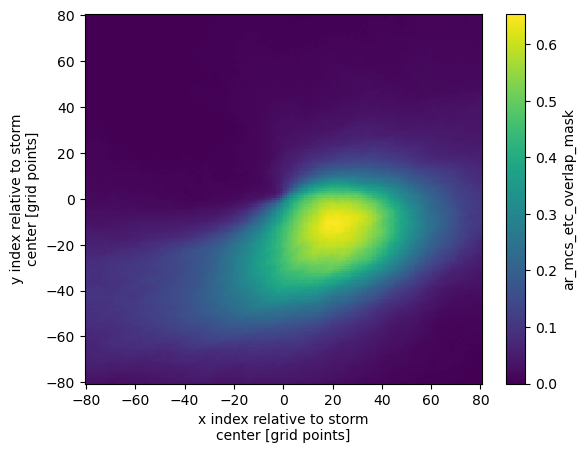

In [15]:
composites_nh['3way'].ar_mcs_etc_overlap_mask.plot()

In [16]:
# Create composites for all overlap categories
composites = {}

# 0: isolated (no overlaps)
mask_isolated = ds.overlap_flag == 0
composites['isolated'] = ds.where(mask_isolated, drop=False).mean(dim='time', skipna=True)
print(f"Isolated ETC points: {mask_isolated.sum().values}")

# 1: MCS only
mask_mcs_only = ds.overlap_flag == 1
composites['mcs_only'] = ds.where(mask_mcs_only, drop=False).mean(dim='time', skipna=True)
print(f"MCS-only overlap points: {mask_mcs_only.sum().values}")

# 2: AR only
mask_ar_only = ds.overlap_flag == 2
composites['ar_only'] = ds.where(mask_ar_only, drop=False).mean(dim='time', skipna=True)
print(f"AR-only overlap points: {mask_ar_only.sum().values}")

# 3: MCS + AR (3-way)
mask_3way = ds.overlap_flag == 3
composites['3way'] = ds.where(mask_3way, drop=False).mean(dim='time', skipna=True)
print(f"3-way overlap points: {mask_3way.sum().values}")

print(f"\nCreated {len(composites)} composite datasets")

Isolated ETC points: 9238
MCS-only overlap points: 4790
AR-only overlap points: 1206
3-way overlap points: 3653

Created 4 composite datasets
3-way overlap points: 3653

Created 4 composite datasets


## Plot Example Composite

Let's visualize one of the composites to see the spatial pattern.

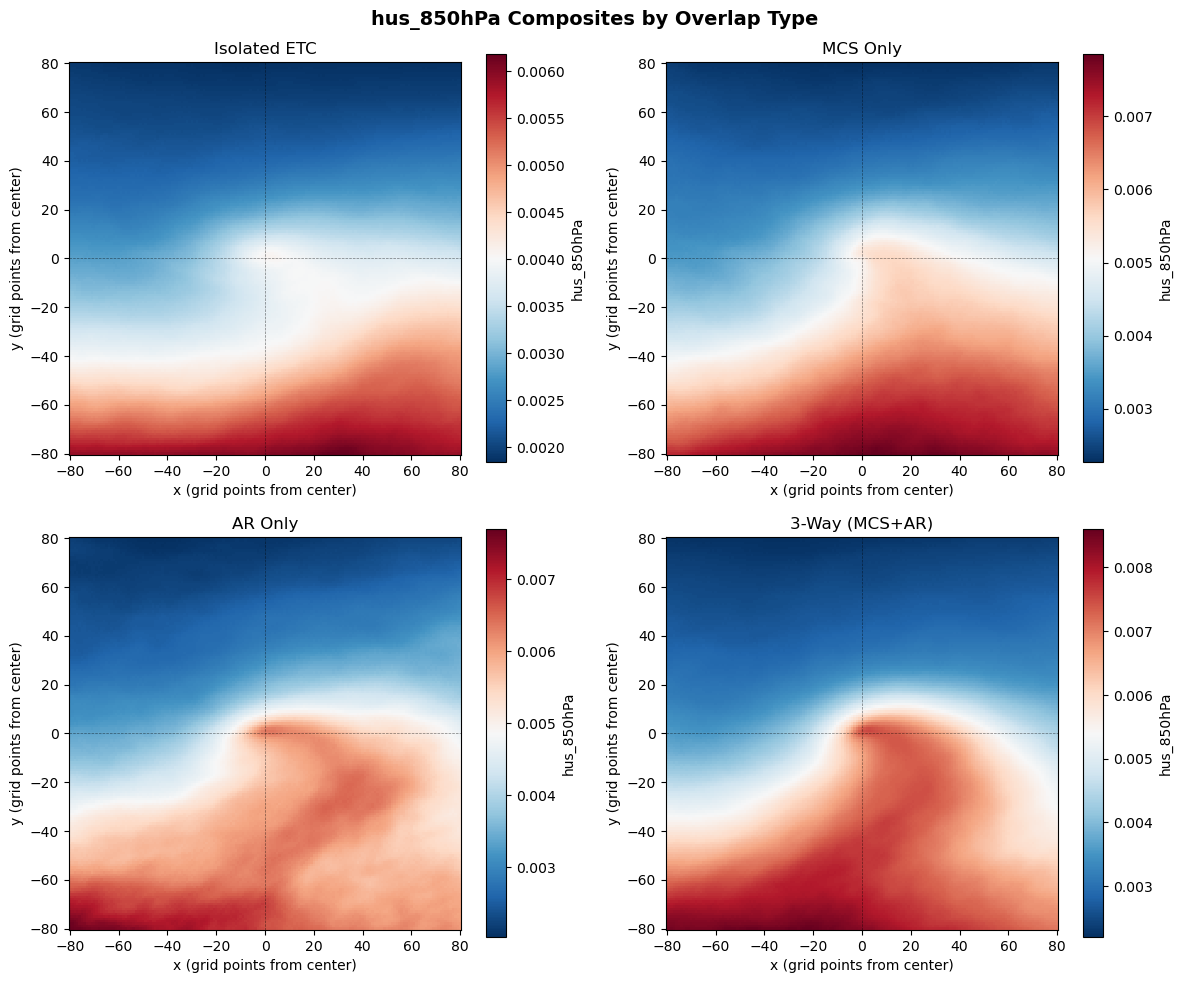

In [17]:
# Plot the first data variable for 3-way composite
if data_vars:
    var_name = 'hus_850hPa'
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'{var_name} Composites by Overlap Type', fontsize=14, fontweight='bold')
    
    titles = ['Isolated ETC', 'MCS Only', 'AR Only', '3-Way (MCS+AR)']
    comp_keys = ['isolated', 'mcs_only', 'ar_only', '3way']
    
    for ax, title, comp_key in zip(axes.flat, titles, comp_keys):
        data = composites_nh[comp_key][var_name].values
        
        im = ax.pcolormesh(ds.x, ds.y, data, shading='auto', cmap='RdBu_r')
        ax.set_title(title)
        ax.set_xlabel('x (grid points from center)')
        ax.set_ylabel('y (grid points from center)')
        ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.set_aspect('equal')
        
        plt.colorbar(im, ax=ax, label=var_name)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data variables found to plot")

## Save Composites (Optional)

You can save the composites to zarr files for later analysis.

In [64]:
composites_nh.keys()

dict_keys(['isolated', 'mcs_only', 'ar_only', '3way'])

In [68]:
# Save composites as compressed NetCDF files

# Compression settings
encoding = {}
for var in composites_nh['isolated'].data_vars:
    encoding[var] = {'zlib': True, 'complevel': 4}

# Save NH composites
print("Saving Northern Hemisphere composites:")
for comp_name, comp_data in composites_nh.items():
    output_path = f"{out_dir}etc_2d_composite_nh_{comp_name}.nc"
    comp_data.to_netcdf(output_path, encoding=encoding)
    print(f"  Saved NH {comp_name}: {output_path}")

# Save SH composites
print("\nSaving Southern Hemisphere composites:")
for comp_name, comp_data in composites_sh.items():
    output_path = f"{out_dir}etc_2d_composite_sh_{comp_name}.nc"
    comp_data.to_netcdf(output_path, encoding=encoding)
    print(f"  Saved SH {comp_name}: {output_path}")

print(f"\nAll composites saved to: {out_dir}")

Saving Northern Hemisphere composites:
  Saved NH isolated: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/scream/etc_2d_composite_nh_isolated.nc
  Saved NH isolated: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/scream/etc_2d_composite_nh_isolated.nc
  Saved NH mcs_only: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/scream/etc_2d_composite_nh_mcs_only.nc
  Saved NH mcs_only: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/scream/etc_2d_composite_nh_mcs_only.nc
  Saved NH ar_only: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/scream/etc_2d_composite_nh_ar_only.nc
  Saved NH ar_only: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/scream/etc_2d_composite_nh_ar_only.nc
  Saved NH 3way: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/scream/etc_2d_composite_nh_3way.nc

Saving Southern Hemisphere composites:
  Saved NH 3way: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/scream/etc_2d_composite_nh_3way.nc

Saving Southern Hemisphere composites:
  Saved SH isolated: /pscratch/sd/w/wcmca1/ha

: 